<a href="https://colab.research.google.com/github/dishidhak/brown_dhakshin_demand_estimation/blob/main/data_analysis_air_fryers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers
### Dishitha Dhakshin (qxk8wp), Emerson Brown (gsz5cv)
## Data Analysis
Welcome! This notebook explores the cleaned air fryer market dataset (2019–2023), and ensures the data is trustworthy, visual, and interpretable before building a model. We perform descriptive analysis to understand pricing, ratings, market shares, and product characteristics before conducting demand estimation.

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
print(df.shape)
print(df.head())

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

## 1. Data Verification

Verifying that the dataset contains 10 brands and covers the years 2019–2023.

In [13]:
print("Number of brands:", df['brand'].nunique())
print("Years:", sorted(df['year'].unique()))

Number of brands: 10
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## 2. Trends Over Time

### Average Price by Brand

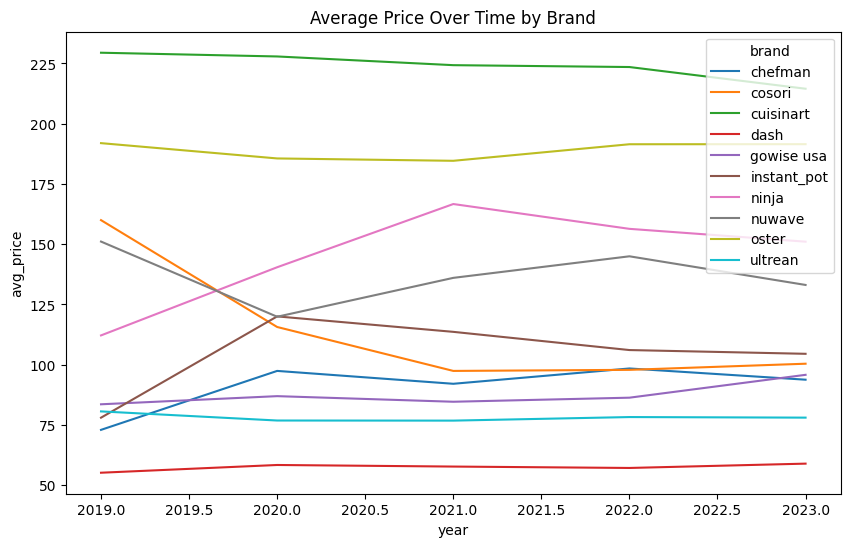

In [14]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='avg_price', hue='brand')
plt.title("Average Price Over Time by Brand")
plt.show()

### Average Rating by Brand

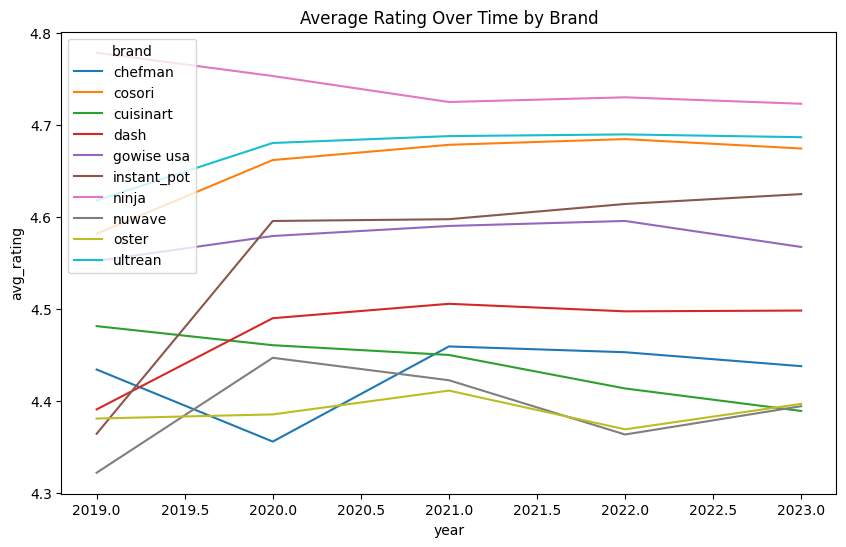

In [15]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='avg_rating', hue='brand')
plt.title("Average Rating Over Time by Brand")
plt.show()

### Market Share by Brand

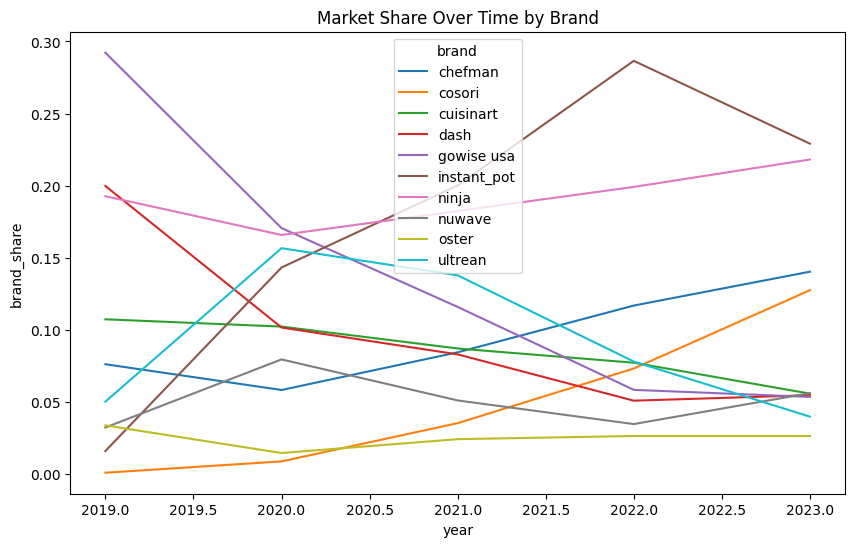

In [16]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='brand_share', hue='brand')
plt.title("Market Share Over Time by Brand")
plt.show()

## 3. Product Characteristics

In [17]:
feature_cols = [
    'compact_share','dual_basket_share','oven_style_share',
    'rotisserie_share','window_share'
]

df[feature_cols].mean().sort_values(ascending=False)

,0
compact_share,0.980081
oven_style_share,0.562647
rotisserie_share,0.070762
window_share,0.036741
dual_basket_share,0.002260


In [18]:
df.groupby('brand')[feature_cols].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


### Which features are rare?

Dual-basket, rotisserie, and windows are the rarest features. Most brands do not offer dual-basket air fryers, with the average share across brands being close to 0%. About 7% of products have a rotisserie design, the window feature appears in about 4%.

### Which features are common?
Compact and oven style features are most common. About 98% of products are categorized as compact share, and around 56% as oven style. Compact air fryers are the most common feature, with an average share of about 98% across all brands.

### Are there brands that seem to specialize in different product types?
Cuisinart, Dash, Oster, and Ultrean seem to focus on oven-style air fryers. Chefman stands out for offering rotisserie and window features compared to its competitors.

## 4. Market Summary

Prices vary widely across brands. Cuisinart, a premium brand, consistently priced the highest. On the contrary, brands like Dash and Ultrean remained the cheapest for almost the entire 2019-2023 time frame. Observe brands like Ninja, Instant Pot, and Chefman gradually increasing their prices before stabalizing, a deliberate pricing strategy to optimize profitability.

Ratings are relatively high and stable across all brands, ranging from about
4.3 - 4.8 out of 5. Ninja consistently maintained the highest ratings across all years, reinforcing its industry stance as a premium brand. Overall, our analysis depicts a market differentiated through pricing and product features rather than large differences in perceived quality.

Market share is concentrated among a few dominant brands. We can observe Instant Pot experiencing significant growth, becoming the largest market share holder by 2022. On the contrary, brands like GoWISE USA and Dash decline over time. This indicates shifting competitive dynamics but no major market disruption.